## Analog hand eraser

In [19]:
import csv
import random
from pathlib import Path
import json
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [20]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Paths
DATA_DIR = Path("data")
TRAIN_CSV = DATA_DIR / "train_labels.csv"
TEST_CSV = DATA_DIR / "test_labels.csv"

CHECKPOINT_DIR = Path("outputs/checkpoints")
PREVIEW_DIR = Path("outputs/eraser_previews")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparameters
IMAGE_SIZE = 256
BATCH_SIZE = 8
NUM_EPOCHS = 60
LEARNING_RATE = 1e-4

Device: cpu


In [21]:
class ClockEraserDataset(Dataset):
    """
    Dataset for the analog hand eraser task.

    Input:
        Analog clock image with hands.

    Target:
        The same analog clock image without hands.
    """

    def __init__(self, csv_path, transform=None):
        self.rows = []
        self.transform = transform

        with open(csv_path, mode="r", encoding="utf-8") as file:
            reader = csv.DictReader(file)
            for row in reader:
                self.rows.append(row)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows[index]

        input_image = Image.open(row["analog_path"]).convert("RGB")
        target_image = Image.open(row["analog_without_hands_path"]).convert("RGB")

        if self.transform is not None:
            input_image = self.transform(input_image)
            target_image = self.transform(target_image)

        return input_image, target_image

In [22]:
# Basic image preprocessing.
# Images are resized and converted to tensors in range [0, 1].
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = ClockEraserDataset(TRAIN_CSV, transform=transform)
test_dataset = ClockEraserDataset(TEST_CSV, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 300
Test samples: 100


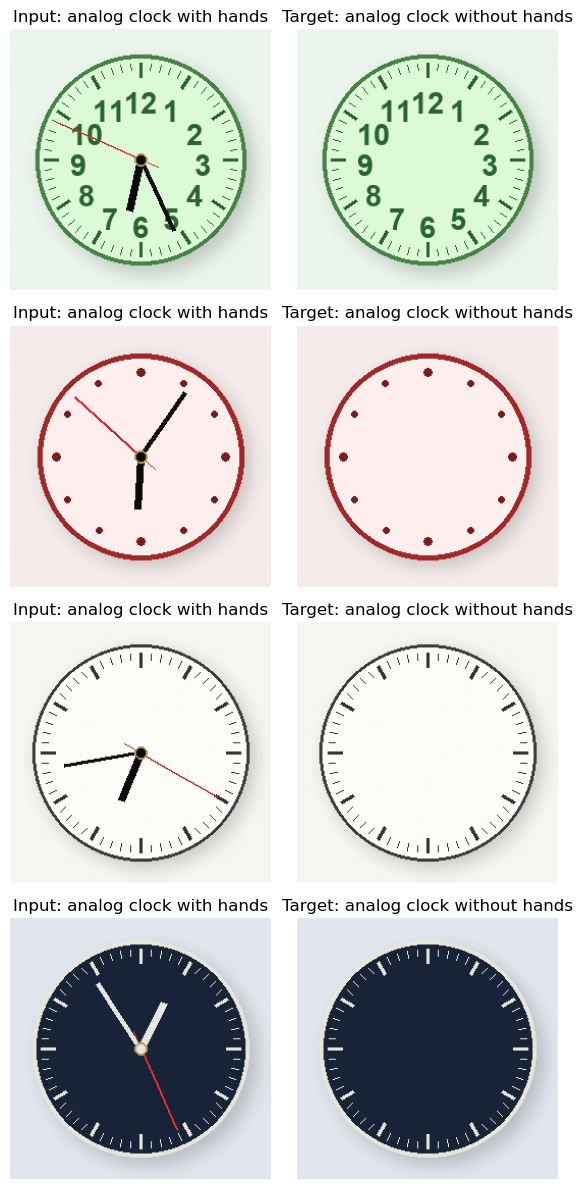

In [23]:
def show_dataset_samples(dataset, num_samples=4):
    """
    Display random input-target pairs from the dataset.
    """

    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    fig, axes = plt.subplots(len(indices), 2, figsize=(6, 3 * len(indices)))

    if len(indices) == 1:
        axes = [axes]

    for row_index, sample_index in enumerate(indices):
        input_image, target_image = dataset[sample_index]

        input_image = input_image.permute(1, 2, 0).numpy()
        target_image = target_image.permute(1, 2, 0).numpy()

        axes[row_index][0].imshow(input_image)
        axes[row_index][0].set_title("Input: analog clock with hands")
        axes[row_index][0].axis("off")

        axes[row_index][1].imshow(target_image)
        axes[row_index][1].set_title("Target: analog clock without hands")
        axes[row_index][1].axis("off")

    plt.tight_layout()
    plt.show()


show_dataset_samples(train_dataset)

In [24]:
class DoubleConv(nn.Module):
    """
    Two consecutive convolution layers with BatchNorm and ReLU.
    Used as the basic building block of the U-Net.
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [25]:
class SmallUNet(nn.Module):
    """
    Small U-Net for image-to-image reconstruction.

    The skip connections help preserve fine visual details from the input image,
    which is important for reconstructing clock faces.
    """

    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(kernel_size=2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        # Output layer
        self.output_layer = nn.Conv2d(32, 3, kernel_size=1)
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder with skip connections
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.output_activation(self.output_layer(d1))


model = SmallUNet().to(device)
print(model)

SmallUNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_siz

In [26]:
class CombinedReconstructionLoss(nn.Module):
    """
    Combines L1 and MSE losses.

    L1 helps preserve structure and reduces excessive blurring.
    MSE helps improve pixel-level color accuracy.
    """

    def __init__(self, mse_weight=0.1):
        super().__init__()
        self.l1 = nn.L1Loss()
        self.mse = nn.MSELoss()
        self.mse_weight = mse_weight

    def forward(self, prediction, target):
        l1_loss = self.l1(prediction, target)
        mse_loss = self.mse(prediction, target)

        return l1_loss + self.mse_weight * mse_loss


criterion = CombinedReconstructionLoss(mse_weight=0.1)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [27]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    """

    model.train()
    total_loss = 0.0

    for input_images, target_images in dataloader:
        input_images = input_images.to(device)
        target_images = target_images.to(device)

        optimizer.zero_grad()

        predicted_images = model(input_images)
        loss = criterion(predicted_images, target_images)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input_images.size(0)

    return total_loss / len(dataloader.dataset)


def evaluate(model, dataloader, criterion, device):
    """
    Evaluate the model on validation/test data.
    """

    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for input_images, target_images in dataloader:
            input_images = input_images.to(device)
            target_images = target_images.to(device)

            predicted_images = model(input_images)
            loss = criterion(predicted_images, target_images)

            total_loss += loss.item() * input_images.size(0)

    return total_loss / len(dataloader.dataset)

In [28]:
def save_prediction_preview(model, dataloader, epoch, output_dir, device, num_images=4):
    """
    Save a visual preview:
    Row 1: input images
    Row 2: model predictions
    Row 3: target images
    """

    model.eval()

    input_images, target_images = next(iter(dataloader))
    input_images = input_images.to(device)
    target_images = target_images.to(device)

    with torch.no_grad():
        predicted_images = model(input_images)

    input_images = input_images[:num_images].cpu()
    predicted_images = predicted_images[:num_images].cpu()
    target_images = target_images[:num_images].cpu()

    grid = make_grid(
        torch.cat([input_images, predicted_images, target_images], dim=0),
        nrow=num_images
    )

    preview_image = transforms.ToPILImage()(grid)

    output_path = output_dir / f"epoch_{epoch:03d}.png"
    preview_image.save(output_path)

    print("Saved preview:", output_path)

In [ ]:
best_test_loss = float("inf")
history = []

patience = 7
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS + 1):

    # ===== Train =====
    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    # ===== Evaluate =====
    test_loss = evaluate(
        model=model,
        dataloader=test_loader,
        criterion=criterion,
        device=device
    )

    # ===== Scheduler step =====
    scheduler.step(test_loss)

    # ===== Save history =====
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "test_loss": test_loss,
    })

    print(
        f"Epoch [{epoch}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.5f} | "
        f"Test Loss: {test_loss:.5f}"
    )

    # ===== Check improvement =====
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        epochs_without_improvement = 0

        checkpoint_path = CHECKPOINT_DIR / "best_eraser_unet.pth"
        torch.save(model.state_dict(), checkpoint_path)

        print("Saved best model:", checkpoint_path)

    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s)")

        # ===== Early stopping =====
        if epochs_without_improvement >= patience:
            print("Early stopping triggered")
            break

    # ===== Save preview =====
    if epoch == 1 or epoch % 5 == 0:
        save_prediction_preview(
            model=model,
            dataloader=test_loader,
            epoch=epoch,
            output_dir=PREVIEW_DIR,
            device=device
        )

Epoch [1/60] | Train Loss: 0.33756 | Test Loss: 0.31751
Saved best model: outputs\checkpoints\best_eraser_unet.pth
Saved preview: outputs\eraser_previews\epoch_001.png
Epoch [2/60] | Train Loss: 0.28330 | Test Loss: 0.29007
Saved best model: outputs\checkpoints\best_eraser_unet.pth
Epoch [3/60] | Train Loss: 0.26658 | Test Loss: 0.27415
Saved best model: outputs\checkpoints\best_eraser_unet.pth


In [ ]:
import json

history_path = "outputs/eraser_history.json"

with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print("Saved history to:", history_path)

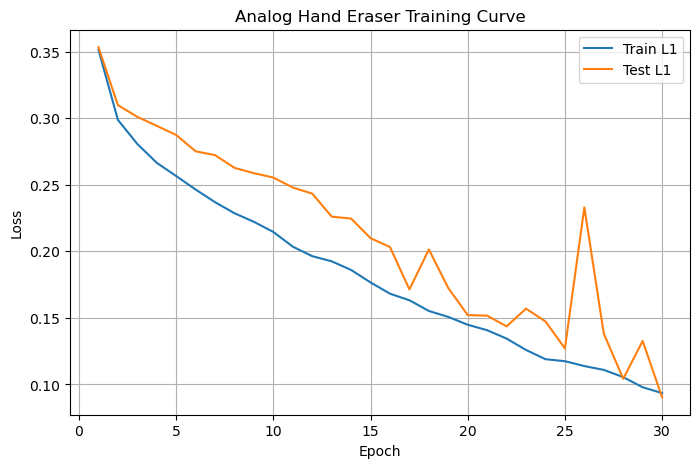

In [ ]:
epochs = [item["epoch"] for item in history]
train_losses = [item["train_loss"] for item in history]
test_losses = [item["test_loss"] for item in history]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train L1")
plt.plot(epochs, test_losses, label="Test L1")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Analog Hand Eraser Training Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_model_path = CHECKPOINT_DIR / "best_eraser_unet.pth"

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

save_prediction_preview(
    model=model,
    dataloader=test_loader,
    epoch=999,
    output_dir=PREVIEW_DIR,
    device=device
)

Saved preview: outputs\eraser_previews\epoch_999.png
